In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn.metrics import accuracy_score, confusion_matrix
from helper.algorithms import ClassificationAlgorithms
# joblib for seving the model
import joblib

In [2]:

# Plot settings
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

In [3]:
df = pd.read_pickle("../processed_data/modelData.pkl")
df = df.drop("epoch (ms)", axis=1)

In [4]:
df_train = df.drop(["Participants", "Category", "Set"], axis=1)

X = df_train.drop("Label", axis=1)
y = df_train["Label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

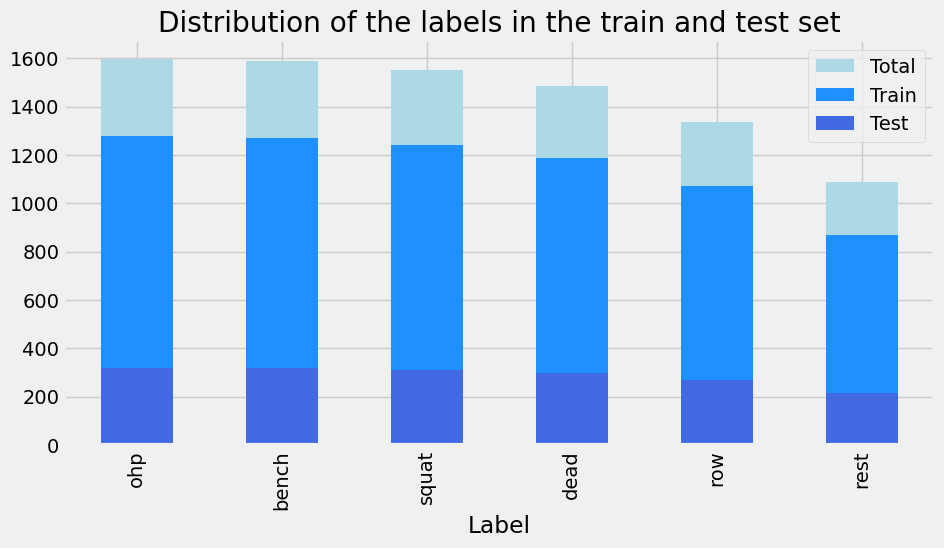

In [5]:
# create a plot
fig, ax = plt.subplots(figsize=(10, 5))
df_train["Label"].value_counts().plot(
    kind="bar", ax=ax, color = "lightblue", label="Total"
   )
y_train.value_counts().plot(kind="bar", ax=ax, color = "dodgerblue", label="Train")
y_test.value_counts().plot(kind="bar", ax=ax, color = "royalblue", label="Test")
plt.legend()
plt.title("Distribution of the labels in the train and test set")
plt.show()


In [6]:
df.columns

Index(['Accelerometer_x', 'Accelerometer_y', 'Accelerometer_z', 'Gyroscope_x',
       'Gyroscope_y', 'Gyroscope_z', 'Participants', 'Label', 'Category',
       'Set', 'pca_1', 'pca_2', 'pca_3', 'Accelerometer_r', 'Gyroscope_r',
       'Accelerometer_x_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5',
       'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_x_temp_mean_ws_5',
       'Gyroscope_y_temp_mean_ws_5', 'Gyroscope_z_temp_mean_ws_5',
       'Accelerometer_r_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5',
       'cluster_acc', 'cluster_gyro'],
      dtype='object')

In [7]:
# split the features 
basic_features = ["Accelerometer_x", "Accelerometer_y", "Accelerometer_z", "Gyroscope_x", "Gyroscope_y", "Gyroscope_z"]
squere_feactures = ["Accelerometer_r", "Gyroscope_r"]
temp_mean_features = [col for col in df.columns if "temp_mean_ws_5" in col]
pca_feactures = ["pca_1", "pca_2", "pca_3"]
cluster_feactures = ["cluster_acc", "cluster_gyro"]

print(f"Basic features: ", len(basic_features))
print(f"Squere features: ", len(squere_feactures))
print(f"Temp mean features: ", len(temp_mean_features))
print(f"PCA features: ", len(pca_feactures))
print(f"Cluster features: ", len(cluster_feactures))


Basic features:  6
Squere features:  2
Temp mean features:  8
PCA features:  3
Cluster features:  2


In [8]:
# creating the feature sets
feature_set_1 = list(set(basic_features))
feature_set_2 = list(set(feature_set_1 + squere_feactures))
feature_set_3 = list(set(feature_set_2 + temp_mean_features))
feature_set_4 = list(set(feature_set_3 + pca_feactures))
feature_set_5 = list(set(feature_set_4 + cluster_feactures))

In [9]:
# preform forword selection using decision tree
X_train = X_train.select_dtypes(exclude=['datetime64[ns]'])

# select 10 best features
learner = ClassificationAlgorithms()

max_features = 10
selected_features, ordered_scores = learner.forward_selection(max_features, X_train, y_train)

Starting forward selection...
Selecting feature 1/10...
After selecting feature 1/10, selected features: ['pca_1']
Selecting feature 2/10...
After selecting feature 2/10, selected features: ['pca_1', 'Accelerometer_z_temp_mean_ws_5']
Selecting feature 3/10...
After selecting feature 3/10, selected features: ['pca_1', 'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5']
Selecting feature 4/10...
After selecting feature 4/10, selected features: ['pca_1', 'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5']
Selecting feature 5/10...
After selecting feature 5/10, selected features: ['pca_1', 'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5', 'Accelerometer_r_temp_mean_ws_5']
Selecting feature 6/10...
After selecting feature 6/10, selected features: ['pca_1', 'Accelerometer_z_temp_mean_ws_5', 'Gyroscope_r_temp_mean_ws_5', 'Accelerometer_y_temp_mean_ws_5', 'Accelerometer_r_temp_mean_ws_5', 

Text(0.5, 1.0, 'Forward selection')

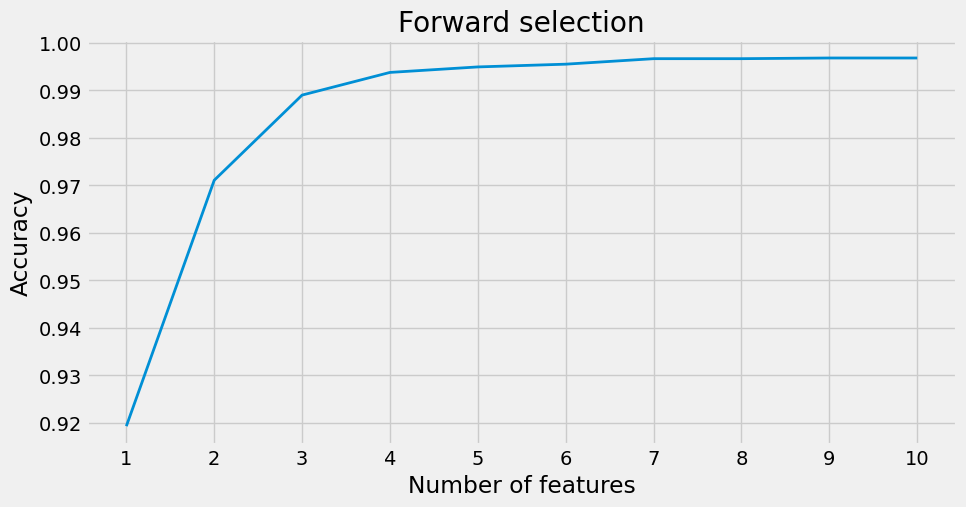

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, max_features + 1, 1), ordered_scores)
plt.xlabel("Number of features")
plt.ylabel("Accuracy")
plt.xticks(np.arange(1, max_features + 1, 1))
plt.title("Forward selection")


In [11]:
# feature sets
possible_feature_sets = [feature_set_1, feature_set_2, feature_set_3, feature_set_4,  feature_set_5, selected_features]
feature_names = ["Feature Set 1", "Feature Set 2", "Feature Set 3", "Feature Set 4","Feature Set 5", "Selected features"]

iterations = 1
score_df = pd.DataFrame()

# iterate over feature sets
for i, f in enumerate(feature_names):
    print("Feature set:", i)
    selected_train_X = X_train[possible_feature_sets[i]]
    selected_test_X = X_test[possible_feature_sets[i]]

    # Random Forest
    print("\tTraining random forest")
    performance_test_rf = sum(
        accuracy_score(y_test, learner.random_forest(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])
        for _ in range(iterations)
    ) / iterations

    # KNN
    print("\tTraining KNN")
    performance_test_knn = accuracy_score(y_test, learner.k_nearest_neighbor(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Decision Tree
    print("\tTraining decision tree")
    performance_test_dt = accuracy_score(y_test, learner.decision_tree(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Naive Bayes
    print("\tTraining naive bayes")
    performance_test_nb = accuracy_score(y_test, learner.naive_bayes(selected_train_X, y_train, selected_test_X)[1])

    # SVM without kernel
    print("\tTraining SVM without kernel")
    performance_test_svm_no_kernel = accuracy_score(y_test, learner.svm_without_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # SVM with kernel
    #print("\tTraining SVM with kernel")
    #performance_test_svm_kernel = accuracy_score(y_test, learner.svm_with_kernel(selected_train_X, y_train, selected_test_X, gridsearch=True)[1])

    # Save results to dataframe
    new_scores = pd.DataFrame({
        "model": ["RF", "KNN", "DT", "NB", "SVM-No-Kernel"], # can add SVM with kernel
        "feature_set": f,
        "accuracy": [performance_test_rf, performance_test_knn, performance_test_dt, performance_test_nb, performance_test_svm_no_kernel], # performance_test_svm_kernel
    })
    
    score_df = pd.concat([score_df, new_scores], ignore_index=True)


Feature set: 0
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 1
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 2
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 3
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 4
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel
Feature set: 5
	Training random forest
	Training KNN
	Training decision tree
	Training naive bayes
	Training SVM without kernel


In [12]:
score_df.sort_values(by="accuracy", ascending=False, inplace=True)
score_df

,model,feature_set,accuracy
10,RF,Feature Set 3,0.989589
20,RF,Feature Set 5,0.988433
15,RF,Feature Set 4,0.987854
12,DT,Feature Set 3,0.979757
25,RF,Selected features,0.978600
22,DT,Feature Set 5,0.975130
17,DT,Feature Set 4,0.973395
5,RF,Feature Set 2,0.968190
27,DT,Selected features,0.967033
0,RF,Feature Set 1,0.963563


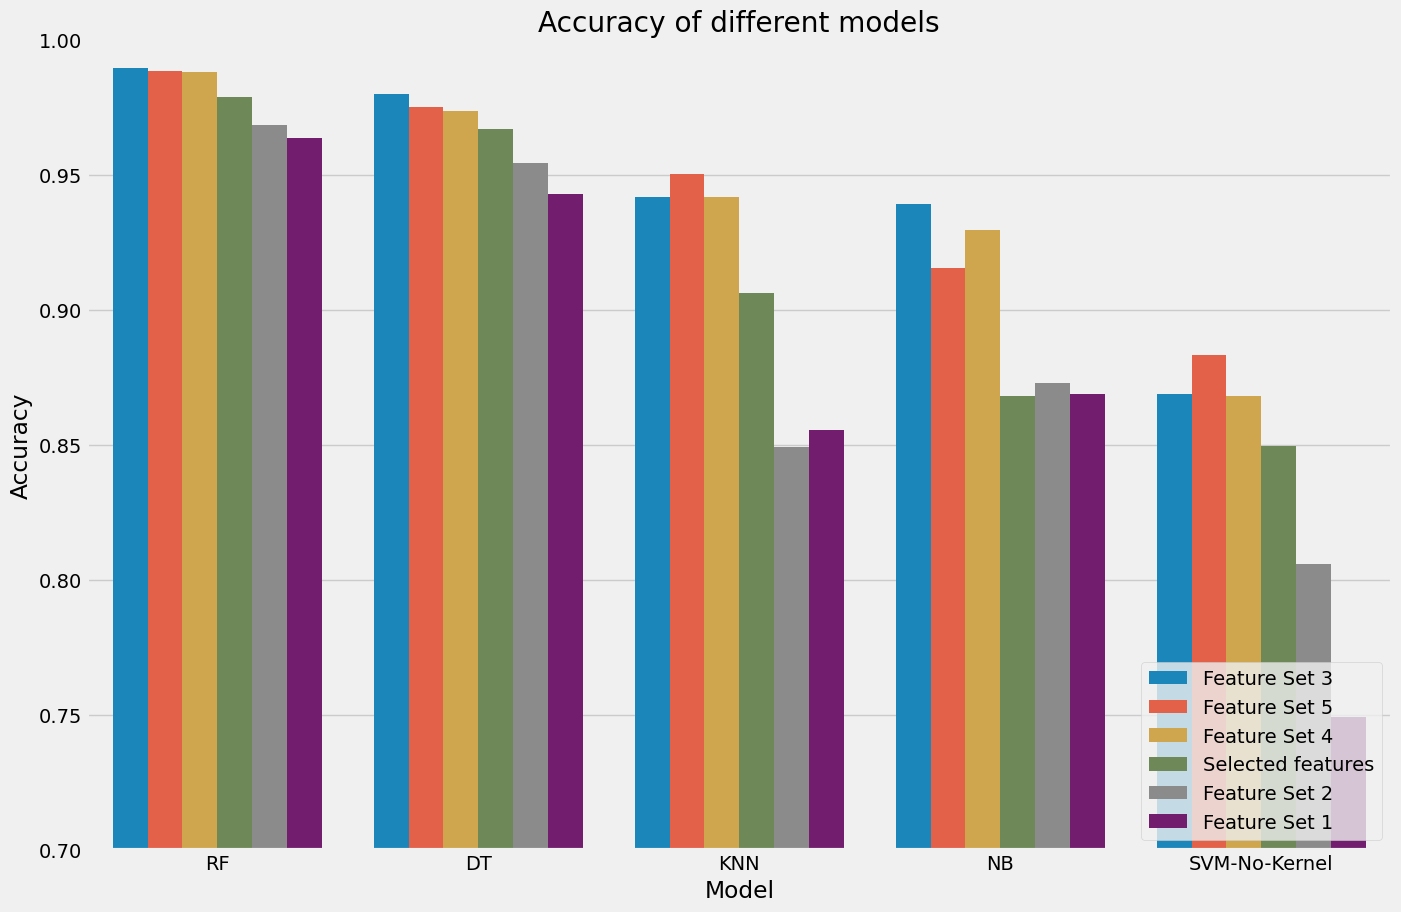

In [13]:
plt.figure(figsize=(15, 10))
sns.barplot(x="model", y="accuracy", hue="feature_set", data=score_df)
plt.title("Accuracy of different models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1)
plt.legend(loc="lower right")
plt.show()

In [17]:
# random forest
pred_train, pred_test, = learner.random_forest(X_train[feature_set_3], y_train, X_test[feature_set_3], gridsearch=True)

In [18]:
# confusion matrix
cm = confusion_matrix(y_test, pred_test, labels=y.unique())
cm

array([[310,   8,   0,   0,   0,   0],
       [  7, 312,   0,   0,   0,   0],
       [  0,   0, 310,   0,   0,   0],
       [  0,   0,   0, 295,   3,   0],
       [  0,   0,   0,   3, 264,   0],
       [  0,   0,   0,   0,   0, 217]])

In [19]:
# print accurrency on test set
accuracy_score(y_test, pred_test)

0.9878542510121457

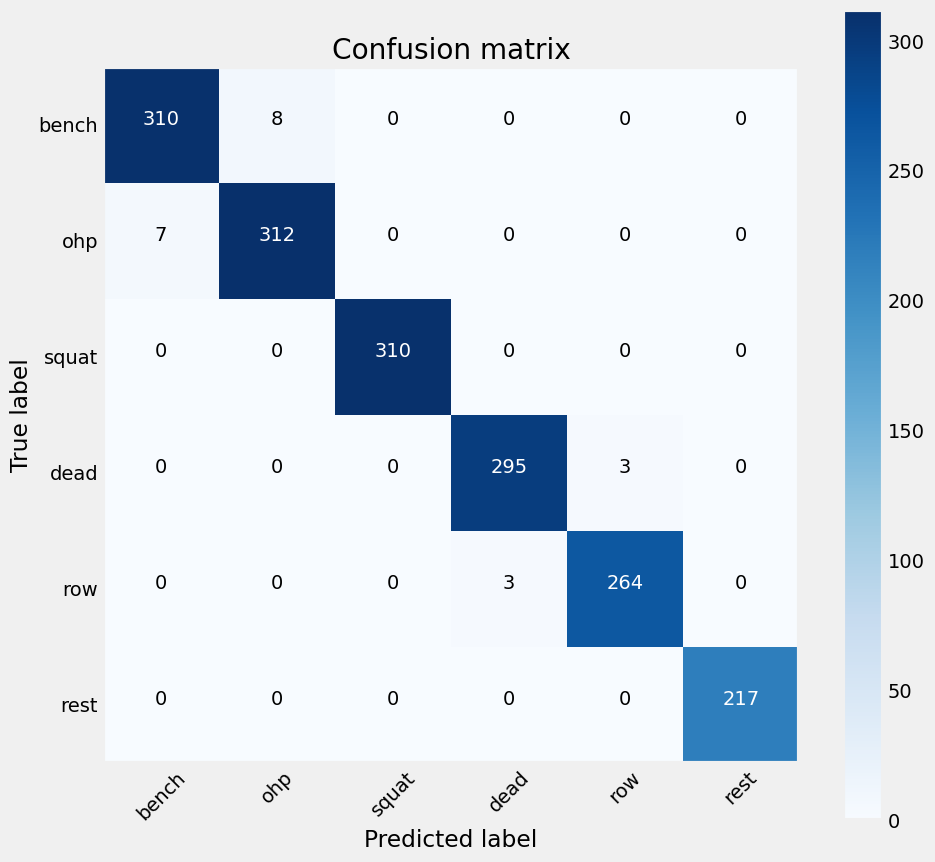

In [20]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

## Check overfitting

In [21]:
# trying the model for overfitting seeing how it proforms on the training set
#pred_train, pred_test, = learner.random_forest(X_train[feature_set_2], y_train, X_train[feature_set_2], gridsearch=True)
cm = confusion_matrix(y_train, pred_train, labels=y.unique())
cm

array([[1271,    0,    0,    0,    0,    0],
       [   0, 1277,    0,    0,    0,    0],
       [   0,    0, 1240,    0,    0,    0],
       [   0,    0,    0, 1189,    0,    0],
       [   0,    0,    0,    0, 1070,    0],
       [   0,    0,    0,    0,    0,  869]])

In [22]:
# perint accuracy
accuracy_score(y_train, pred_train)

1.0

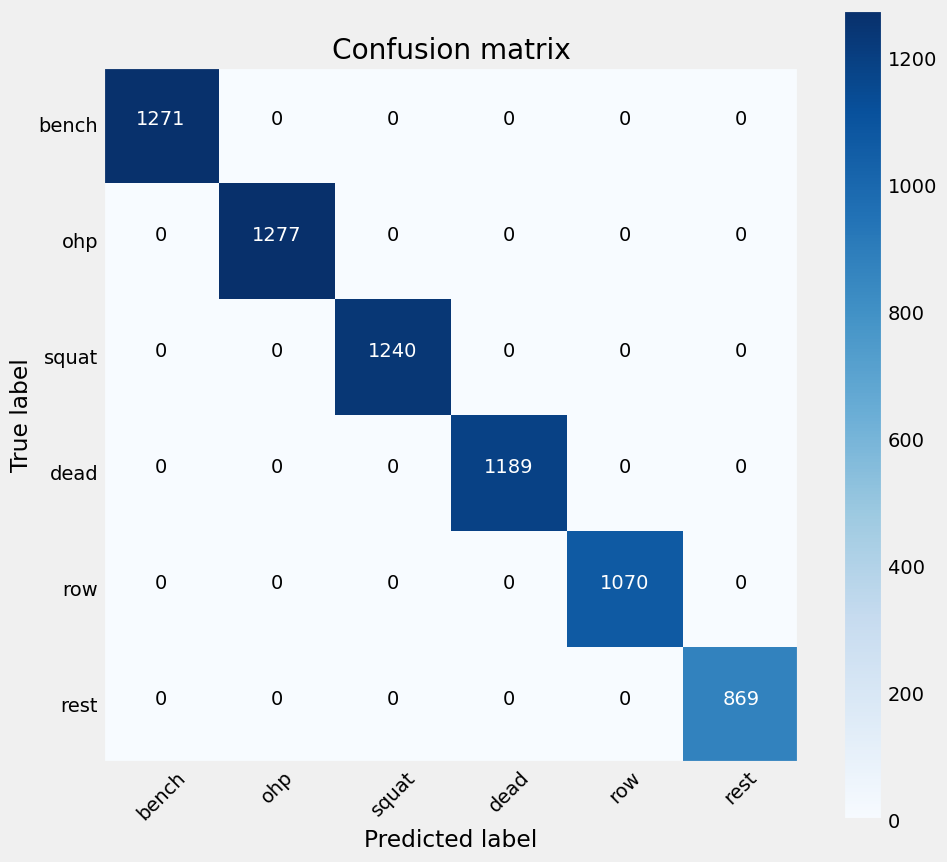

In [23]:
# create confusion matrix for cm
classes = y.unique()

plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

In [24]:
model = learner.random_forest(X_train[feature_set_3], y_train, X_test[feature_set_3], gridsearch=True)[0]

In [ ]:
# save the model
#joblib.dump(model, '../model/random_forest_model.pkl')


['../model/random_forest_model.pkl']